In [1]:
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import polars as pl
import requests
from wordcloud import WordCloud

print("Imports complete.")

Imports complete.


# Katherine McGaughey's Notebook
# Intro to Web Mining & Applied NLP

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Katherine McGaughey](https://github.com/k363m611/)
- Repository: [nlp-01-getting-started](https://github.com/k363m611/nlp-01-getting-started/)
- Purpose: Demonstrate web mining and applied natural language processing (NLP)
- Date: 2026-03

In [2]:
url: str = "https://en.wikipedia.org/wiki/Natural_language_processing"

headers: dict[str, str] = {
    "User-Agent": "Mozilla/5.0 (compatible; NLP-Course-Example/1.0)"
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

html: str = response.text

print(f"Downloaded {len(html):,} characters from:")
print(url)

Downloaded 323,098 characters from:
https://en.wikipedia.org/wiki/Natural_language_processing


In [3]:
soup: BeautifulSoup = BeautifulSoup(html, "lxml")
text: str = soup.get_text(separator=" ", strip=True)

print(text[:1000])

Natural language processing - Wikipedia Jump to content Main menu Main menu move to sidebar hide Navigation Main page Contents Current events Random article About Wikipedia Contact us Contribute Help Learn to edit Community portal Recent changes Upload file Special pages Search Search Appearance Donate Create account Log in Personal tools Donate Create account Log in Contents move to sidebar hide (Top) 1 History Toggle History subsection 1.1 Symbolic NLP (1950s – early 1990s) 1.2 Statistical NLP (1990s–present) 2 Approaches: Symbolic, statistical, neural networks Toggle Approaches: Symbolic, statistical, neural networks subsection 2.1 Statistical approach 2.2 Neural networks 3 Common NLP tasks Toggle Common NLP tasks subsection 3.1 Text and speech processing 3.2 Morphological analysis 3.3 Syntactic analysis 3.4 Lexical semantics (of individual words in context) 3.5 Relational semantics (semantics of individual sentences) 3.6 Discourse (semantics beyond individual sentences) 3.7 Higher-

In [4]:
words = text.split()
words = [w.lower() for w in words]
clean_words = [w.strip(".,:;!?()[]\"'") for w in words if len(w) > 3]

print(clean_words[:20])
print(len(clean_words))

['natural', 'language', 'processing', 'wikipedia', 'jump', 'content', 'main', 'menu', 'main', 'menu', 'move', 'sidebar', 'hide', 'navigation', 'main', 'page', 'contents', 'current', 'events', 'random']
5435


In [5]:
df: pl.DataFrame = pl.DataFrame({"word": clean_words})
freq_df: pl.DataFrame = df.group_by("word").len().sort("len", descending=True)

print(freq_df.head(20))

shape: (20, 2)
┌─────────────┬─────┐
│ word        ┆ len │
│ ---         ┆ --- │
│ str         ┆ u64 │
╞═════════════╪═════╡
│ language    ┆ 110 │
│ natural     ┆ 69  │
│ processing  ┆ 54  │
│ text        ┆ 51  │
│ that        ┆ 41  │
│ …           ┆ …   │
│ edit        ┆ 25  │
│ given       ┆ 25  │
│ retrieved   ┆ 25  │
│ speech      ┆ 24  │
│ statistical ┆ 23  │
└─────────────┴─────┘


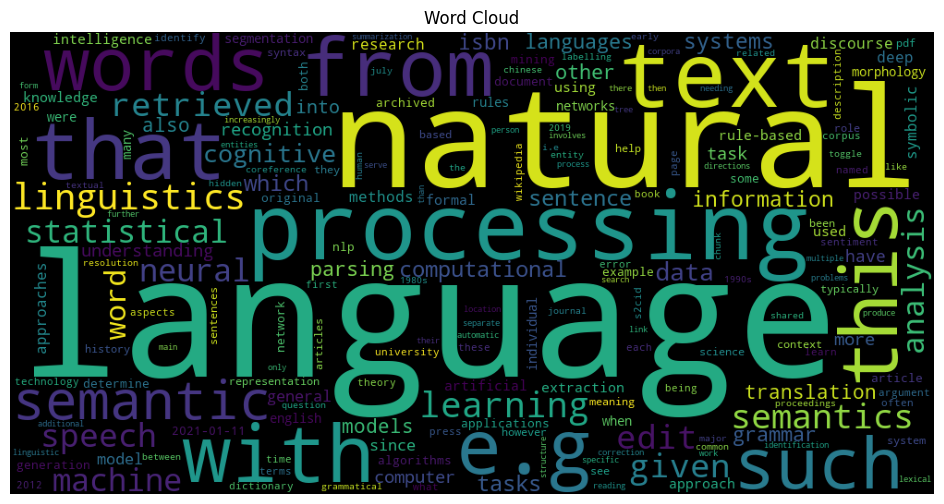

In [6]:
freq_dict: dict[str, int] = dict(
    zip(freq_df["word"].to_list(), freq_df["len"].to_list(), strict=True)
)

wc: WordCloud = WordCloud(width=1000, height=500, background_color="black")
wc.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()